# Generation perplexity during training

List any number of run names below, then run all cells in Colab or a local Jupyter
notebook (CPU is sufficient). In Colab, Drive is mounted automatically. Locally,
set `BASE_DIR` to the folder containing your run directories, either downloaded
or synced with Google Drive for desktop. Each run uses `generation_metrics.jsonl` and `metrics.jsonl`.
No models or datasets are loaded.

Local dependencies: `pip install pandas numpy matplotlib ipykernel` in your notebook
kernel environment. Locally, the notebook uses the configured synced Drive folder
when available, otherwise this repository's `outputs` directory.

On the left axis, dotted lines show **mean per-answer perplexity**, solid lines
show **median perplexity**, and shading shows **25th–75th percentiles (IQR)**. Dashed lines show **validation weighted loss**
from `metrics.jsonl` on the right axis, starting at step 250 by default.
Each run uses the same color on both axes. Only `split="validation"` records
(or the spelling `"alidation"`) are used for loss; training/test records are excluded.
Validation loss is already an aggregate, so it is plotted directly without an IQR.
The two metrics keep their own evaluation steps; no interpolation or alignment is required.
A second, aligned panel shows mean per-answer **Distinct-1/2/3**, computed
in this notebook from each record's final text using sliding lexical n-grams.
Higher Distinct-n means greater lexical diversity. Set `SMOOTHING_WINDOW`
to apply the same trailing running-average window to every plotted metric;
the summary tables remain unsmoothed.

The perplexity IQR describes the spread of answers, not a confidence interval for the mean.
It is different from token-pooled perplexity, which cannot be recovered from
per-answer perplexities alone without their scored token counts.
Compare runs scored with the same reference model/tokenizer and generation protocol.

In [274]:
from pathlib import Path

try:
    from google.colab import drive
except ModuleNotFoundError:
    # Jupyter may start in the repository root or in its notebooks directory.
    project_dir = Path.cwd()
    if project_dir.name == "notebooks":
        project_dir = project_dir.parent
    synced_outputs = Path(
        "/Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/"
        "My Drive/lad-generic-results/outputs"
    )
    DEFAULT_BASE_DIR = synced_outputs if synced_outputs.is_dir() else project_dir / "outputs"
    print(f"Running locally. Run folders: {DEFAULT_BASE_DIR}")
else:
    drive.mount("/content/drive")
    DEFAULT_BASE_DIR = Path("/content/drive/MyDrive/lad-generic-results/outputs")


Running locally. Run folders: /Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/My Drive/lad-generic-results/outputs


In [ ]:
# Edit this list: one directory name per run, with as many runs as you like.
RUN_NAMES = [
    # "llama-3.1-8b-mask-legacy-comparison",
    # "llama-3.1-8b-mask-frontier-2",
    # "llama-3.1-8b-mask-frontier-all-tokens",
    # "llama-3.1-8b-mask-frontier-answer90-padding10",
    "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-2m_1",
    "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5-reproduction",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5-reproduction-withnewfrontierpadding",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5-reproduction-withnewdataset",
    "llama-3.1-8b-mask-iid-alltokens-answerpadding-long-1m",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-6",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-6",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch2-lr1e-5",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch2-lr1e-6",
    # "llama-3.1-8b-mask-frontier-answer90-padding10-long-newdata-epoch2-lr1e-5",
    # "gemma-2-9b-mask-frontier-answer90-padding10",
]
BASE_DIR = DEFAULT_BASE_DIR
# Local override: the directory containing <run>/generation_metrics.jsonl.
# BASE_DIR = Path("~/Downloads/lad-generic-results/outputs").expanduser()
LOG_Y = False
LOG_VALIDATION_LOSS = False
MIN_VALIDATION_STEP = 250  # Include validation loss from this step onward.
SMOOTHING_WINDOW = 1  # Number of logged observations; 1 disables smoothing.



In [276]:
import json
import re
import numpy as np
import pandas as pd
from IPython.display import display


def read_records(path):
    if not path.is_file():
        print(f"File not found (skipping): {path}")
        return pd.DataFrame()
    records, malformed = [], 0
    with path.open() as stream:
        for line in stream:
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                malformed += 1  # A running job may not have finished its last line.
                continue
            if isinstance(record, dict):
                records.append(record)
            else:
                malformed += 1
    if malformed:
        print(f"{path}: skipped {malformed} malformed record(s).")
    frame = pd.DataFrame(records)
    if "step" not in frame:
        return pd.DataFrame()
    frame["step"] = pd.to_numeric(frame["step"], errors="coerce")
    return frame.loc[np.isfinite(frame["step"]) & (frame["step"] >= 0)].copy()


DISTINCT_COLUMNS = ["distinct_1", "distinct_2", "distinct_3"]
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)


def distinct_n(text, n):
    """Return unique sliding lexical n-grams / all sliding lexical n-grams."""
    if not isinstance(text, str) or not text.strip():
        return np.nan
    tokens = TOKEN_PATTERN.findall(text)
    if len(tokens) < n:
        return np.nan
    ngrams = [tuple(tokens[index:index + n]) for index in range(len(tokens) - n + 1)]
    return len(set(ngrams)) / len(ngrams)


perplexity_summaries = {}
distinct_summaries = {}
validation_losses = {}
for run_name in dict.fromkeys(RUN_NAMES):
    run_dir = BASE_DIR / run_name
    generation_frame = read_records(run_dir / "generation_metrics.jsonl")
    if "prompt_index" in generation_frame and generation_frame["prompt_index"].notna().all():
        generation_frame = generation_frame.drop_duplicates(["step", "prompt_index"], keep="last")
    if "generation_perplexity" in generation_frame:
        frame = generation_frame.copy()
        values = pd.to_numeric(frame["generation_perplexity"], errors="coerce")
        valid = np.isfinite(values) & (values > 0)
        if (~valid).any():
            print(f"{run_name}: excluded {int((~valid).sum())} invalid perplexity value(s).")
        frame = frame.loc[valid].copy()
        frame["generation_perplexity"] = values.loc[valid]
        if not frame.empty:
            perplexity_summaries[run_name] = frame.groupby("step", sort=True)["generation_perplexity"].agg(
                mean="mean", median="median", q25=lambda values: values.quantile(0.25),
                q75=lambda values: values.quantile(0.75), n="count",
            )

    if "final" in generation_frame:
        frame = generation_frame[["step", "final"]].copy()
        for n, column in enumerate(DISTINCT_COLUMNS, start=1):
            frame[column] = frame["final"].map(lambda text, n=n: distinct_n(text, n))
        unavailable = frame[DISTINCT_COLUMNS].isna().sum()
        if unavailable.any():
            details = ", ".join(
                f"Distinct-{n}: {int(unavailable[column])}"
                for n, column in enumerate(DISTINCT_COLUMNS, start=1) if unavailable[column]
            )
            print(f"{run_name}: unavailable for empty/short answers — {details}.")
        summary = frame.groupby("step", sort=True)[DISTINCT_COLUMNS].mean().dropna(how="all")
        if not summary.empty:
            distinct_summaries[run_name] = summary

    # Load independently: loss can be available more often than generation metrics.
    frame = read_records(run_dir / "metrics.jsonl")
    if {"split", "weighted_loss"}.issubset(frame.columns):
        frame = frame.loc[frame["split"].isin(["validation", "alidation"])
                          & (frame["step"] >= MIN_VALIDATION_STEP)].copy()
        frame["weighted_loss"] = pd.to_numeric(frame["weighted_loss"], errors="coerce")
        # A resumed run may have logged the same validation step more than once.
        frame = frame.drop_duplicates("step", keep="last")
        valid = np.isfinite(frame["weighted_loss"]) & (frame["weighted_loss"] >= 0)
        if (~valid).any():
            print(f"{run_name}: excluded {int((~valid).sum())} invalid validation loss value(s).")
        frame = frame.loc[valid].sort_values("step")
        if not frame.empty:
            validation_losses[run_name] = frame.set_index("step")["weighted_loss"]
    print(f"{run_name}: {len(perplexity_summaries.get(run_name, []))} perplexity steps, "
          f"{len(distinct_summaries.get(run_name, []))} Distinct-n steps, "
          f"{len(validation_losses.get(run_name, []))} validation loss steps.")

if not perplexity_summaries and not distinct_summaries and not validation_losses:
    raise ValueError("No valid runs found. Check RUN_NAMES, BASE_DIR and MIN_VALIDATION_STEP.")

if perplexity_summaries:
    stats = pd.concat(perplexity_summaries, names=["run", "step"])
    display(stats)
if validation_losses:
    loss_stats = pd.concat(validation_losses, names=["run", "step"]).rename("weighted_loss").to_frame()
    display(loss_stats)
if distinct_summaries:
    distinct_stats = pd.concat(distinct_summaries, names=["run", "step"])
    display(distinct_stats)


llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5: 50 perplexity steps, 50 Distinct-n steps, 200 validation loss steps.
llama-3.1-8b-mask-frontier-answer90-padding10-long-2m_1: 66 perplexity steps, 66 Distinct-n steps, 133 validation loss steps.
llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5-reproduction: 2 perplexity steps, 2 Distinct-n steps, 9 validation loss steps.
llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5-reproduction-withnewfrontierpadding: 9 perplexity steps, 9 Distinct-n steps, 37 validation loss steps.
llama-3.1-8b-mask-frontier-answer90-padding10-long-epoch1-lr1e-5-reproduction-withnewdataset: 7 perplexity steps, 7 Distinct-n steps, 31 validation loss steps.
llama-3.1-8b-mask-iid-alltokens-answerpadding-long-1m: 1 perplexity steps, 1 Distinct-n steps, 4 validation loss steps.


mean     median  \
run                                                step                         
llama-3.1-8b-mask-frontier-answer90-padding10-l... 1000  10.664366   9.691126   
                                                   2000   8.897559   7.990068   
                                                   3000   8.753841   8.593677   
                                                   4000   9.230808   8.275307   
                                                   5000   8.577666   8.223718   
...                                                            ...        ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 4000   8.720753   8.007061   
                                                   5000  23.774997   9.295405   
                                                   6000   9.375377   8.913493   
                                                   7000   8.769276   7.673443   
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 1000  11.284616  10.722677   

                                                              q25        q75  \
run                                                step                        
llama-3.1-8b-mask-frontier-answer90-padding10-l... 1000  7.932936  11.750654   
                                                   2000  5.959505  10.273293   
                                                   3000  7.259425  10.406070   
                                                   4000  6.284102  10.450058   
                                                   5000  6.411365   9.095698   
...                                                           ...        ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 4000  6.390359   9.989884   
                                                   5000  7.260592  11.667398   
                                                   6000  6.574976  10.425644   
                                                   7000  6.401640   9.675689   
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 1000  9.259133  13.912023   

                                                          n  
run                                                step      
llama-3.1-8b-mask-frontier-answer90-padding10-l... 1000  30  
                                                   2000  30  
                                                   3000  30  
                                                   4000  30  
                                                   5000  30  
...                                                      ..  
llama-3.1-8b-mask-frontier-answer90-padding10-l... 4000  30  
                                                   5000  30  
                                                   6000  30  
                                                   7000  30  
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 1000  30  

[135 rows x 5 columns]

weighted_loss
run                                                step               
llama-3.1-8b-mask-frontier-answer90-padding10-l... 250        2.162577
                                                   500        1.964657
                                                   750        1.884811
                                                   1000       1.806645
                                                   1250       1.747000
...                                                                ...
llama-3.1-8b-mask-frontier-answer90-padding10-l... 7750       1.344122
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 250        0.586305
                                                   500        0.509389
                                                   750        0.483398
                                                   1000       0.483757

[414 rows x 1 columns]

distinct_1  \
run                                                step               
llama-3.1-8b-mask-frontier-answer90-padding10-l... 1000    0.378635   
                                                   2000    0.383782   
                                                   3000    0.384508   
                                                   4000    0.368122   
                                                   5000    0.405160   
...                                                             ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 4000    0.404954   
                                                   5000    0.363915   
                                                   6000    0.430053   
                                                   7000    0.398230   
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 1000    0.398161   

                                                         distinct_2  \
run                                                step               
llama-3.1-8b-mask-frontier-answer90-padding10-l... 1000    0.644642   
                                                   2000    0.675917   
                                                   3000    0.680574   
                                                   4000    0.647267   
                                                   5000    0.705795   
...                                                             ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 4000    0.692575   
                                                   5000    0.641389   
                                                   6000    0.759913   
                                                   7000    0.681245   
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 1000    0.701872   

                                                         distinct_3  
run                                                step              
llama-3.1-8b-mask-frontier-answer90-padding10-l... 1000    0.762470  
                                                   2000    0.800811  
                                                   3000    0.812246  
                                                   4000    0.778201  
                                                   5000    0.823537  
...                                                             ...  
llama-3.1-8b-mask-frontier-answer90-padding10-l... 4000    0.811060  
                                                   5000    0.759210  
                                                   6000    0.878396  
                                                   7000    0.806829  
llama-3.1-8b-mask-iid-alltokens-answerpadding-l... 1000    0.826072  

[135 rows x 3 columns]

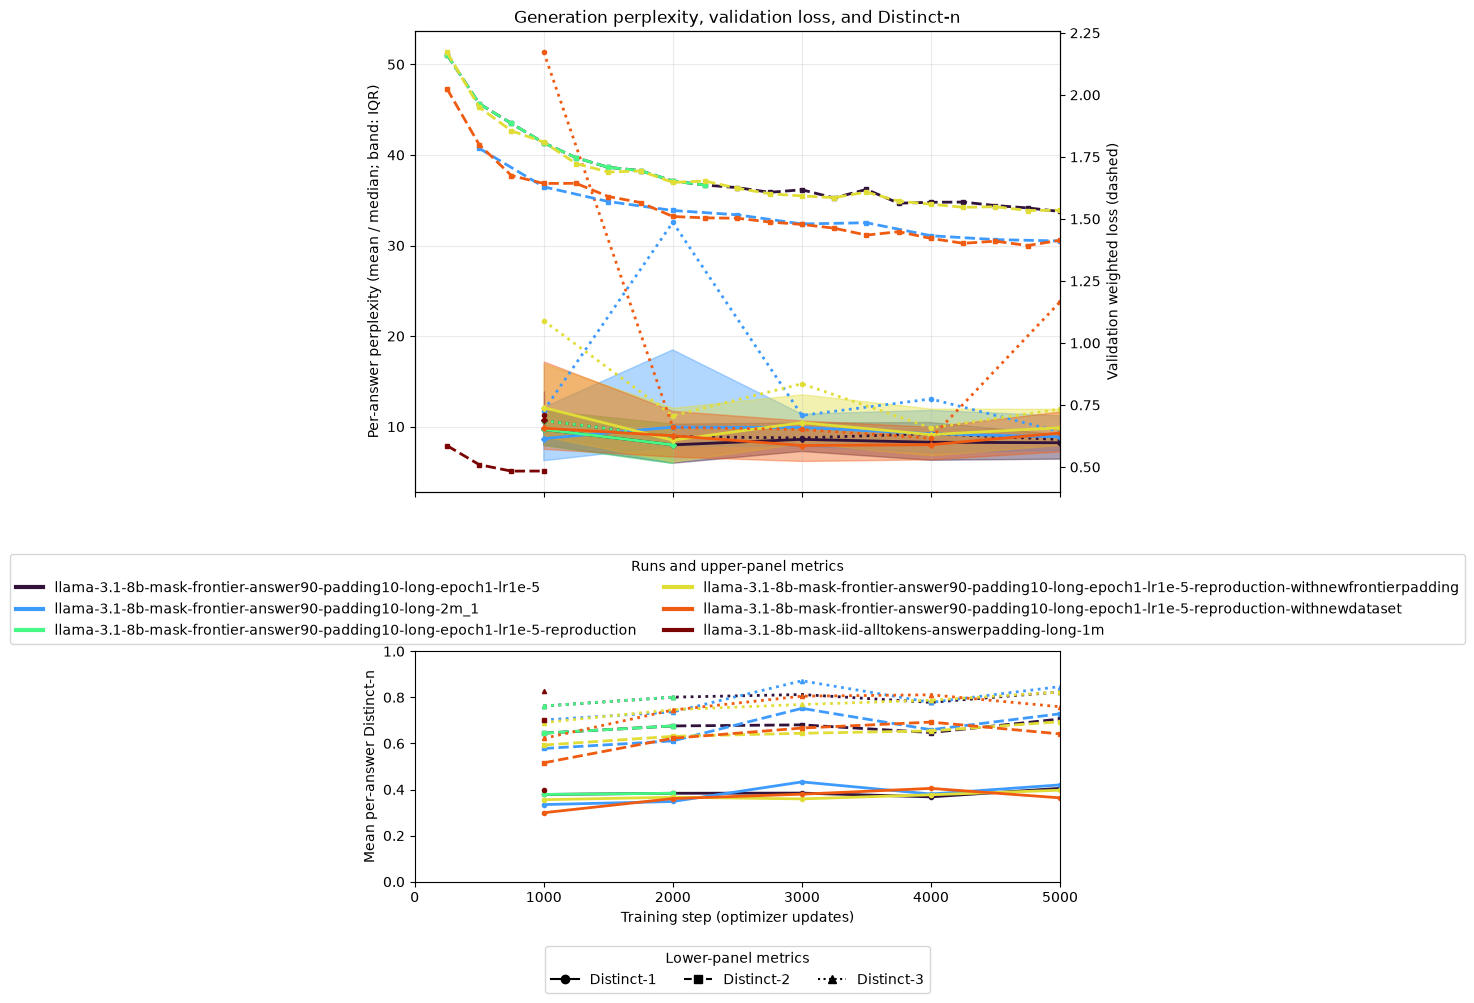

In [277]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if not isinstance(SMOOTHING_WINDOW, int) or isinstance(SMOOTHING_WINDOW, bool) or SMOOTHING_WINDOW < 1:
    raise ValueError("SMOOTHING_WINDOW must be a positive integer")


def running_average(values):
    """Apply the configured trailing average without altering stored summaries."""
    return pd.Series(np.asarray(values, dtype=float)).rolling(
        window=SMOOTHING_WINDOW, min_periods=1
    ).mean().to_numpy()

fig, (ax, distinct_ax) = plt.subplots(
    2, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
loss_ax = ax.twinx()
plotted_runs = [name for name in dict.fromkeys(RUN_NAMES)
                if name in perplexity_summaries or name in distinct_summaries
                or name in validation_losses]
colors = plt.get_cmap("turbo" if len(plotted_runs) <= 20 else "turbo")
legend_handles = []
for index, run_name in enumerate(plotted_runs):
    color = colors(index / max(len(plotted_runs) - 1, 1))
    legend_handles.append(Line2D([], [], color=color, linewidth=3, label=run_name))
    summary = perplexity_summaries.get(run_name)
    if summary is not None:
        steps = summary.index.to_numpy(dtype=float)
        ax.plot(steps, running_average(summary["mean"]), color=color,
                linewidth=2, linestyle=":", marker="o", markersize=3)
        ax.plot(steps, running_average(summary["median"]), color=color,
                linewidth=2, linestyle="-", marker="D", markersize=3)
        ax.fill_between(steps, running_average(summary["q25"]), running_average(summary["q75"]),
                        color=color, alpha=0.4)
    loss = validation_losses.get(run_name)
    if loss is not None:
        loss_ax.plot(loss.index.to_numpy(dtype=float), running_average(loss), color=color,
                     linewidth=2, linestyle="--", marker="s", markersize=3)
    distinct = distinct_summaries.get(run_name)
    if distinct is not None:
        distinct_steps = distinct.index.to_numpy(dtype=float)
        distinct_styles = {
            "distinct_1": ("-", "o"),
            "distinct_2": ("--", "s"),
            "distinct_3": (":", "^"),
        }
        for column, (linestyle, marker) in distinct_styles.items():
            if column in distinct:
                distinct_ax.plot(
                    distinct_steps, running_average(distinct[column]), color=color,
                    linewidth=2, linestyle=linestyle, marker=marker, markersize=3,
                )


if LOG_Y:
    ax.set_yscale("log")
if LOG_VALIDATION_LOSS:
    loss_ax.set_yscale("log", nonpositive="mask")  # Zero loss has no finite log value.
smoothing_note = ("" if SMOOTHING_WINDOW == 1
                  else f" ({SMOOTHING_WINDOW}-observation running average)")
ax.set(title=f"Generation perplexity, validation loss, and Distinct-n{smoothing_note}",
       ylabel="Per-answer perplexity (mean / median; band: IQR)")
loss_ax.set_ylabel("Validation weighted loss (dashed)")
ax.grid(True, alpha=0.25)
distinct_ax.set(
    xlabel="Training step (optimizer updates)",
    ylabel="Mean per-answer Distinct-n",
)
distinct_ax.set_ylim(0, 1)

ax.legend(
    handles=legend_handles,
    title="Runs and upper-panel metrics",
    bbox_to_anchor=(0.5, -0.12),
    loc="upper center",
    ncol=2,
)

distinct_ax.legend(
    handles=[
        Line2D([], [], color="black", linestyle="-", marker="o", label="Distinct-1"),
        Line2D([], [], color="black", linestyle="--", marker="s", label="Distinct-2"),
        Line2D([], [], color="black", linestyle=":", marker="^", label="Distinct-3"),
    ],
    title="Lower-panel metrics",
    bbox_to_anchor=(0.5, -0.25),
    loc="upper center",
    ncol=3,
)

fig.subplots_adjust(hspace=0.55, bottom=0.20)

distinct_ax.set_xlim(0, 5_000)
fig.tight_layout(rect=(0, 0, 1, 1))
plt.show()

# Optional: save the displayed figure to Drive.
# fig.savefig(BASE_DIR.parent / "generation-quality-comparison.png", dpi=200, bbox_inches="tight")


In [278]:
from pathlib import Path
import random
import html

from datasets import load_from_disk
from IPython.display import HTML, display

# Works when the notebook is in either the repository root or notebooks/.
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATASETS = {
    "Epoch 1 dataset": PROJECT_DIR / "data/lad-training-1m-256-long",
    "Epoch 2 dataset": PROJECT_DIR / "data/lad-training-1m-256-long-epoch2",
}

SPLIT = "train"
NUM_EXAMPLES = 10
SEED = 421
MAX_TEXT_CHARS = 2_000  # Set to None to show complete texts.


def shorten(value):
    text = str(value or "")
    if MAX_TEXT_CHARS and len(text) > MAX_TEXT_CHARS:
        return text[:MAX_TEXT_CHARS] + "\n[…truncated for display…]"
    return text


def show_random_examples(name, dataset, count, seed):
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), min(count, len(dataset)))

    display(HTML(f"<h2>{html.escape(name)} — {html.escape(SPLIT)}</h2>"))

    for position, index in enumerate(indices, start=1):
        row = dataset[index]
        metadata = {
            "row": index,
            "category": row.get("category"),
            "source": row.get("source"),
            "sample_origin": row.get("sample_origin", "original_dataset"),
            "answer_truncated": row.get("answer_truncated"),
            "answer_words": len((row.get("output") or "").split()),
            "sequence_tokens": len(row.get("input_ids") or []),
        }

        fields = [
            ("System", row.get("system")),
            ("Instruction", row.get("instruction")),
            ("Input", row.get("input")),
            ("Output", row.get("output")),
        ]

        field_html = "".join(
            f"""
            <h4 style="margin-bottom:4px">{html.escape(label)}</h4>
            <pre style="white-space:pre-wrap; overflow-wrap:anywhere;
                        background:#f6f8fa; padding:10px; border-radius:6px">
{html.escape(shorten(value))}
            </pre>
            """
            for label, value in fields
            if value
        )

        metadata_html = " · ".join(
            f"<b>{html.escape(str(key))}</b>: {html.escape(str(value))}"
            for key, value in metadata.items()
        )

        display(HTML(
            f"""
            <div style="border:1px solid #bbb; border-radius:8px;
                        padding:14px; margin:12px 0">
                <h3 style="margin-top:0">Example {position}</h3>
                <div>{metadata_html}</div>
                {field_html}
            </div>
            """
        ))


for offset, (name, path) in enumerate(DATASETS.items()):
    if not path.is_dir():
        print(f"Dataset not found: {path}")
        continue

    dataset = load_from_disk(str(path))[SPLIT]
    show_random_examples(name, dataset, NUM_EXAMPLES, SEED + offset)

In [279]:
from pathlib import Path
import sys
import random
import html

import torch
import yaml
from datasets import load_dataset, load_from_disk
from transformers import AutoTokenizer
from IPython.display import display, HTML

# ---------------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------------

SEED = 1
TRAINING_BATCH_SIZE = 16   # Padding depends on the longest item in this batch
NUM_TO_SHOW = 10

DATASETS = {
    "First dataset": "data/lad-training-1m-256-long",
    "Second dataset": "data/lad-training-1m-256-long-epoch2",
}

CONFIG_PATH = "configs/llama3_8b_mask_colab_continued.yaml"

# "configured": use the YAML's 75% frontier / 25% IID mixture
# "frontier":   force frontier masking
# "iid":        force IID masking
MASKING_MODE = "configured"


# ---------------------------------------------------------------------------
# Locate repository
# ---------------------------------------------------------------------------

root = Path.cwd().resolve()

if not (root / "src").exists() and (root.parent / "src").exists():
    root = root.parent

if not (root / "src" / "diffusion_lm").exists():
    raise RuntimeError("Run this notebook from the lad-generic repository or its notebooks folder.")

sys.path.insert(0, str(root / "src"))

from diffusion_lm.data import (
    DenoisingCollator,
    prepare_mask_only_cache_record,
)


# ---------------------------------------------------------------------------
# Load configuration and tokenizer
# ---------------------------------------------------------------------------

with open(root / CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

tokenizer = AutoTokenizer.from_pretrained(
    config["tokenizer_name_or_path"],
    cache_dir=str(root / config.get("cache_dir", "data/huggingface")),
)

frontier_probability = {
    "configured": float(config.get("frontier_masking_probability", 0.0)),
    "frontier": 1.0,
    "iid": 0.0,
}[MASKING_MODE]

collator = DenoisingCollator(
    tokenizer=tokenizer,
    corruption_mode=config["corruption_mode"],
    max_sequence_length=int(config["max_sequence_length"]),
    include_answer_eos=bool(config.get("include_answer_eos", True)),
    pad_to_multiple_of=config.get("pad_to_multiple_of"),
    structured_loss_behavior=config.get(
        "structured_loss_behavior", "all_answer_tokens"
    ),
    eos_padding_loss=config.get("eos_padding_loss"),
    seed=SEED,
    deterministic=False,  # Match training-time online masking
    t_min=float(config.get("t_min", 0.001)),
    multi_turn_prob=0.0,
    max_history_turns=int(config.get("max_history_turns", 2)),
    mask_token=str(config.get("mask_token", "MASK")),
    frontier_masking_probability=frontier_probability,
    frontier_masking_epsilon=float(
        config.get("frontier_masking_epsilon", 0.03)
    ),
    frontier_masking_tau=float(config.get("frontier_masking_tau", 3.0)),
)

mask_token_id = collator.mask_info["mask_token_id"]


# ---------------------------------------------------------------------------
# Dataset and rendering helpers
# ---------------------------------------------------------------------------

def load_dataset_spec(spec):
    path = root / spec

    if path.exists():
        dataset = load_from_disk(str(path))
    else:
        dataset = load_dataset(spec)

    return dataset["train"] if hasattr(dataset, "keys") and "train" in dataset else dataset


def sample_usable_batch(dataset, rng):
    """Sample a full training-sized batch and prepare it exactly as training does."""
    raw_rows = []
    prepared_rows = []
    chosen = set()

    while len(prepared_rows) < TRAINING_BATCH_SIZE:
        index = rng.randrange(len(dataset))
        if index in chosen:
            continue
        chosen.add(index)

        row = dict(dataset[index])
        if not (row.get("output") or "").strip():
            continue

        row["_index"] = index
        prepared = prepare_mask_only_cache_record(
            row,
            tokenizer,
            int(config["max_sequence_length"]),
            bool(config.get("include_answer_eos", True)),
        )

        if not prepared["_lad_usable"]:
            continue

        raw_rows.append((index, row))
        prepared_rows.append(prepared)

    return raw_rows, prepared_rows


COLORS = {
    "prompt": "color:#666;",
    "visible_answer": "color:#111;background:#e8f5e9;",
    "masked_answer": "color:#9c1c1c;background:#ffcdd2;font-weight:bold;",
    "visible_padding": "color:#777;background:#eeeeee;",
    "masked_padding": "color:#8a4b00;background:#ffe0b2;font-weight:bold;",
}


def token_kind(token_id, is_answer, is_padding):
    if token_id == mask_token_id:
        return "masked_padding" if is_padding else "masked_answer"
    if is_padding:
        return "visible_padding"
    if is_answer:
        return "visible_answer"
    return "prompt"


def render_sequence(batch, row_number):
    input_ids = batch["input_ids"][row_number].tolist()
    answer_mask = batch["answer_mask"][row_number].tolist()
    padding_mask = batch["padding_mask"][row_number].tolist()

    pieces = []
    start = 0

    while start < len(input_ids):
        kind = token_kind(
            input_ids[start],
            answer_mask[start],
            padding_mask[start],
        )

        end = start + 1
        while end < len(input_ids):
            next_kind = token_kind(
                input_ids[end],
                answer_mask[end],
                padding_mask[end],
            )
            if next_kind != kind:
                break
            end += 1

        ids = input_ids[start:end]

        if kind == "masked_answer":
            text = " ".join(["⟦MASK⟧"] * len(ids))
        elif kind == "masked_padding":
            text = f" ⟦MASK × {len(ids)}: EOS padding⟧ "
        elif kind == "visible_padding":
            text = f" ⟨EOS padding × {len(ids)}⟩ "
        else:
            text = tokenizer.decode(ids, skip_special_tokens=False)

        pieces.append(
            f'<span style="{COLORS[kind]}">{html.escape(text)}</span>'
        )
        start = end

    return "".join(pieces)


def render_example(dataset_name, raw_info, batch, row_number):
    original_index, raw = raw_info

    answer_mask = batch["answer_mask"][row_number]
    padding_mask = batch["padding_mask"][row_number]
    input_ids = batch["input_ids"][row_number]
    loss_mask = batch["loss_mask"][row_number]

    masked = input_ids == mask_token_id
    answer_tokens = int(answer_mask.sum())
    masked_answer = int((masked & answer_mask).sum())
    padding_tokens = int(padding_mask.sum())
    masked_padding = int((masked & padding_mask).sum())
    supervised_tokens = int(loss_mask.sum())
    sampled_t = float(batch["sampled_t"][row_number])

    metadata = (
        f"<b>{html.escape(dataset_name)}</b> · row {original_index:,} · "
        f"category: {html.escape(str(raw.get('category', '?')))} · "
        f"source: {html.escape(str(raw.get('source', '?')))}<br>"
        f"<b>sampled t:</b> {sampled_t:.3f} · "
        f"<b>answer masked:</b> {masked_answer}/{answer_tokens} · "
        f"<b>padding masked:</b> {masked_padding}/{padding_tokens} · "
        f"<b>loss positions:</b> {supervised_tokens}"
    )

    legend = """
    <span style="background:#e8f5e9;padding:2px 5px;">visible answer</span>
    <span style="background:#ffcdd2;padding:2px 5px;">masked answer</span>
    <span style="background:#ffe0b2;padding:2px 5px;">masked EOS padding</span>
    """

    body = render_sequence(batch, row_number)

    return f"""
    <div style="border:1px solid #ccc;border-radius:8px;padding:14px;margin:12px 0;">
        <div style="margin-bottom:8px;">{metadata}</div>
        <div style="margin-bottom:10px;font-size:12px;">{legend}</div>
        <div style="
            white-space:pre-wrap;
            font-family:ui-monospace,monospace;
            line-height:1.55;
            border-top:1px solid #ddd;
            padding-top:10px;
        ">{body}</div>
    </div>
    """


# ---------------------------------------------------------------------------
# Generate and show previews
# ---------------------------------------------------------------------------

rng = random.Random(SEED)

for dataset_number, (dataset_name, dataset_spec) in enumerate(DATASETS.items()):
    dataset = load_dataset_spec(dataset_spec)
    raw_rows, prepared_rows = sample_usable_batch(dataset, rng)

    # Reproducible preview, while still using training's nondeterministic branch.
    torch.manual_seed(SEED + dataset_number)
    batch = collator(prepared_rows)

    display(HTML(
        f"<h2>{html.escape(dataset_name)}</h2>"
        f"<p>Masking mode: <b>{MASKING_MODE}</b>; "
        f"batch size: <b>{TRAINING_BATCH_SIZE}</b></p>"
    ))

    for row_number in range(min(NUM_TO_SHOW, len(raw_rows))):
        display(HTML(render_example(
            dataset_name,
            raw_rows[row_number],
            batch,
            row_number,
        )))